In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import CIFAR10
from torchvision import transforms
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR
import math
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import timm
from timm.loss import LabelSmoothingCrossEntropy, SoftTargetCrossEntropy
from timm.data import Mixup

In [2]:
class ConvStem(nn.Module):
    """Small CNN that downsamples to a feature grid."""
    def __init__(self, img_size=32, embed_dim=256, num_stages=3):
        super().__init__()
        layers = []
        in_ch = 3
        chs = [embed_dim // 4, embed_dim // 2, embed_dim]  # for 3 stages
        for i, out_ch in enumerate(chs):
            if i < num_stages - 1:
                layers.append(nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1))
                layers.append(nn.BatchNorm2d(out_ch))
                layers.append(nn.GELU())
            else:
                layers.append(nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1))
            in_ch = out_ch
        self.stem = nn.Sequential(*layers)
        self.grid_size = 8

    def forward(self, x):
        return self.stem(x)

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv_proj = nn.Linear(embed_dim, embed_dim * 3)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.size()
        qkv = self.qkv_proj(x).view(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn = F.softmax(scores, dim=-1)
        attn = self.attn_drop(attn)
        context = (attn @ v).transpose(1, 2).contiguous().view(B, N, D)
        return self.proj_drop(self.out_proj(context))

class FeedForward(nn.Module):  # SwiGLU
    def __init__(self, embed_dim, expansion=4, dropout=0.1):
        super().__init__()
        hidden_dim = int(embed_dim * expansion * 2 / 3)
        self.w_gate = nn.Linear(embed_dim, hidden_dim, bias=False)
        self.w_value = nn.Linear(embed_dim, hidden_dim, bias=False)
        self.w_out = nn.Linear(hidden_dim, embed_dim, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        gate = torch.sigmoid(self.w_gate(x)) * self.w_gate(x)  # Swish
        value = self.w_value(x)
        x = gate * value
        return self.dropout(self.w_out(x))

class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, expansion=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.mlp = FeedForward(embed_dim, expansion, dropout)
        self.ls1 = nn.Parameter(torch.full((embed_dim,), 1e-4))
        self.ls2 = nn.Parameter(torch.full((embed_dim,), 1e-4))

    def forward(self, x):
        x = x + self.ls1 * self.attn(self.norm1(x))
        x = x + self.ls2 * self.mlp(self.norm2(x))
        return x

class MIMDecoder(nn.Module):
    """Lightweight decoder for masked feature reconstruction."""
    def __init__(self, embed_dim, num_patches, num_layers=2, num_heads=4):
        super().__init__()
        self.num_patches = num_patches
        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.decoder_pos_embed = nn.Parameter(torch.randn(1, num_patches, embed_dim))
        self.blocks = nn.ModuleList([
            EncoderBlock(embed_dim, num_heads, dropout=0.0) for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.pred = nn.Linear(embed_dim, embed_dim)

    def forward(self, x, ids_keep):
        # x: visible encoder patch tokens (B, len_keep, C)
        # ids_keep: indices of these tokens in the original grid (from ids_shuffle[:, :len_keep])
        B, N_vis, C = x.shape
        total_patches = self.num_patches
    
        # Full sequence of mask tokens
        mask_tokens = self.mask_token.expand(B, total_patches, -1)
    
        # Place the visible tokens at their original positions
        full_x = mask_tokens.clone()
        full_x.scatter_(1, ids_keep.unsqueeze(-1).expand(-1, -1, C), x)
    
        # Add decoder positional embeddings
        full_x = full_x + self.decoder_pos_embed
    
        for blk in self.blocks:
            full_x = blk(full_x)
        full_x = self.norm(full_x)
        return self.pred(full_x)

class MIMSmallViT(nn.Module):
    def __init__(self, img_size=32, embed_dim=384, num_heads=4, num_blocks=4,
                 num_reg_tokens=4, conv_stages=3, mask_ratio=0.6, decoder_layers=2):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.num_reg_tokens = num_reg_tokens
        self.stem = ConvStem(img_size, embed_dim, num_stages=conv_stages)
        self.grid_size = self.stem.grid_size
        num_patches = self.grid_size ** 2
        self.num_patches = num_patches

        # Encoder's position embedding (registers + all patches)
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + num_reg_tokens, embed_dim))
        self.reg_tokens = nn.Parameter(torch.randn(1, num_reg_tokens, embed_dim))
        self.blocks = nn.ModuleList([
            EncoderBlock(embed_dim, num_heads, dropout=0.0) for _ in range(num_blocks)
        ])
        self.decoder = MIMDecoder(embed_dim, num_patches, decoder_layers, num_heads)
        # No PEG during MIM

    def forward(self, x):
        B = x.size(0)
        # 1. Stem -> feature grid
        features = self.stem(x)                                 # (B, C, H, W)
        H, W = self.grid_size, self.grid_size
        features_flat = features.flatten(2).transpose(1, 2)     # (B, N, C)
        N = self.num_patches
        target = features_flat.detach()                         # save full stem features as target
        mean = target.mean(dim=(0,1), keepdim=True)   # per-channel mean
        std = target.std(dim=(0,1), keepdim=True) + 1e-6
        target = (target - mean) / std
    
        # 2. Masking
        len_keep = int(N * (1 - self.mask_ratio))
        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_keep = ids_shuffle[:, :len_keep]
    
        # 3. Select visible features
        x_vis = torch.gather(features_flat, dim=1,
                             index=ids_keep.unsqueeze(-1).expand(-1, -1, features_flat.size(-1)))

        # 4. Attach registers + positional embeddings
        reg = self.reg_tokens.expand(B, -1, -1)
        pos_reg = self.pos_embed[:, :self.num_reg_tokens, :]
        pos_patches = self.pos_embed[:, self.num_reg_tokens:, :]  # (1, N, C)
        pos_vis = pos_patches.expand(B, -1, -1).gather(1, ids_keep.unsqueeze(-1).expand(-1, -1, pos_patches.size(-1)))
        x_vis = torch.cat([reg, x_vis], dim=1)
        x_vis = x_vis + torch.cat([pos_reg.expand(B, -1, -1), pos_vis], dim=1)
    
        # 5. Encoder
        for blk in self.blocks:
            x_vis = blk(x_vis)
    
        # 6. Remove registers for decoder
        x_enc_patches = x_vis[:, self.num_reg_tokens:, :]   # (B, len_keep, C)
    
        # 7. Decoder predicts all stem features
        pred = self.decoder(x_enc_patches, ids_keep)        # (B, N, C)
    
        # 8. Loss on masked positions only
        mask = torch.ones(B, N, dtype=torch.bool, device=x.device)  # start with all True
        mask.scatter_(1, ids_keep, False)                            # set visible to False
        loss = F.mse_loss(pred[mask], target[mask])
        return loss

# MIM again (better)

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = MIMSmallViT(
    img_size=32, embed_dim=384, num_heads=4, num_blocks=4,
    num_reg_tokens=4, conv_stages=3, mask_ratio=0.7, decoder_layers=2
).to(device)

print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

Using device: cuda
11.67M


In [5]:
def get_cifar10_subset():
    transform_mim = transforms.Compose([
        transforms.RandomResizedCrop(32, scale=(0.2, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])

    full_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform_mim)
    # Select 100 images per class
    targets = np.array(full_dataset.targets)
    indices = []
    for c in range(10):
        c_idx = np.where(targets == c)[0]
        indices.extend(np.random.choice(c_idx, 100, replace=False))
    subset = Subset(full_dataset, indices)
    return subset


dataset = get_cifar10_subset()
loader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
print(len(dataset))

100%|██████████| 170M/170M [04:16<00:00, 664kB/s] 


1000


In [6]:
num_epochs = 800
optimizer = optim.AdamW(model.parameters(), lr=1.5e-4, weight_decay=0.05)
warmup = LinearLR(optimizer, start_factor=0.01, total_iters=40)
cosine = CosineAnnealingLR(optimizer, T_max=num_epochs - 40)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[40])
losses = []

for epoch in range(1, num_epochs+1):
    model.train()
    epoch_loss = 0.0
    
    for imgs, _ in loader:
        imgs = imgs.to(device)
        
        optimizer.zero_grad()
        loss = model(imgs)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: average loss = {avg_loss:.6f}")

torch.save(model.state_dict(), 'mim_vit.pth')

Epoch 10: average loss = 1.224935
Epoch 20: average loss = 0.559273
Epoch 30: average loss = 0.355139
Epoch 40: average loss = 0.326615
Epoch 50: average loss = 0.249918
Epoch 60: average loss = 0.250820
Epoch 70: average loss = 0.229006
Epoch 80: average loss = 0.241149
Epoch 90: average loss = 0.209370
Epoch 100: average loss = 0.209028
Epoch 110: average loss = 0.208285
Epoch 120: average loss = 0.202399
Epoch 130: average loss = 0.195271
Epoch 140: average loss = 0.195029
Epoch 150: average loss = 0.197332
Epoch 160: average loss = 0.194580
Epoch 170: average loss = 0.187726
Epoch 180: average loss = 0.185013
Epoch 190: average loss = 0.177703
Epoch 200: average loss = 0.183331
Epoch 210: average loss = 0.184427
Epoch 220: average loss = 0.184356
Epoch 230: average loss = 0.177828
Epoch 240: average loss = 0.174786
Epoch 250: average loss = 0.173616
Epoch 260: average loss = 0.176600
Epoch 270: average loss = 0.180413
Epoch 280: average loss = 0.180084
Epoch 290: average loss = 0.1

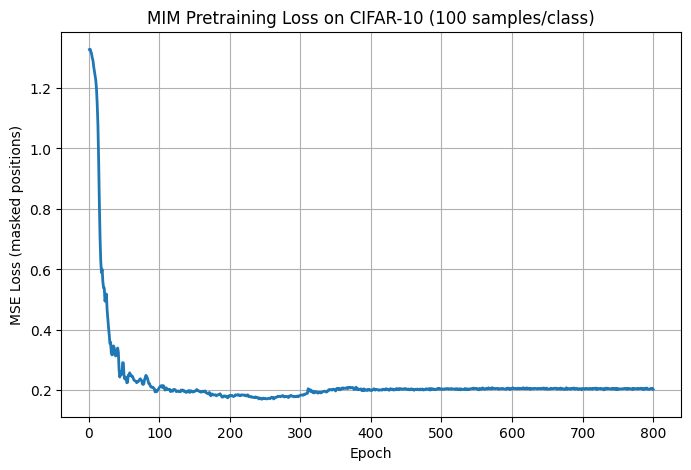

In [8]:
# Plot loss
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (masked positions)')
plt.title('MIM Pretraining Loss on CIFAR-10 (100 samples/class)')
plt.grid(True)
plt.savefig('mim_loss_plot.png')
plt.show()

In [13]:
class PEG(nn.Module):
    def __init__(self, dim, kernel_size=3):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=kernel_size,
                                stride=1, padding=kernel_size//2, groups=dim)

    def forward(self, x, H, W):
        B, N, C = x.shape
        x_2d = x.reshape(B, H, W, C).permute(0, 3, 1, 2)
        x_2d = self.dwconv(x_2d) + x_2d
        return x_2d.permute(0, 2, 3, 1).reshape(B, N, C)

class SmallViT(nn.Module):
    def __init__(self, img_size=32, num_classes=10, embed_dim=384, num_heads=4,
                 num_blocks=4, dropout=0.1, num_reg_tokens=4, conv_stages=3):
        super().__init__()
        self.num_reg_tokens = num_reg_tokens
        self.stem = ConvStem(img_size, embed_dim, num_stages=conv_stages)
        self.grid_size = self.stem.grid_size
        num_patches = self.grid_size ** 2

        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + num_reg_tokens, embed_dim))
        self.reg_tokens = nn.Parameter(torch.randn(1, num_reg_tokens, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            EncoderBlock(embed_dim, num_heads, dropout=dropout)
            for _ in range(num_blocks)
        ])
        self.peg = PEG(embed_dim)
        self.grid_H = self.grid_W = self.grid_size

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def get_features(self, x):
        B = x.size(0)
        x = self.stem(x)                      # (B, C, H, W)
        H, W = self.grid_H, self.grid_W
        x = x.flatten(2).transpose(1, 2)      # (B, N, C)

        reg = self.reg_tokens.expand(B, -1, -1)
        x = torch.cat([reg, x], dim=1)

        seq_len = x.size(1)
        x = x + self.pos_embed[:, :seq_len, :]
        x = self.pos_drop(x)

        for i, blk in enumerate(self.blocks):
            x = blk(x)
            if i == 0:
                patches = x[:, self.num_reg_tokens:]
                patches = self.peg(patches, H, W)
                x = torch.cat([x[:, :self.num_reg_tokens], patches], dim=1)

        x = x.mean(dim=1)                     # GAP
        x = self.norm(x)
        return x

    def forward(self, x):
        features = self.get_features(x)
        return self.head(features), features

In [14]:
def get_cifar10_train_val(seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    full_dataset = CIFAR10('./data', train=True, download=True)
    targets = np.array(full_dataset.targets)
    train_idx, val_idx = [], []
    for c in range(10):
        c_idx = np.where(targets == c)[0]
        np.random.shuffle(c_idx)
        # Take 200 samples per class, split into train/val
        subset = c_idx[:200]
        train_idx.extend(subset[:100])
        val_idx.extend(subset[100:200])
    return train_idx, val_idx

train_idx, val_idx = get_cifar10_train_val()

# Augmentations
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(32, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])
val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_dataset = CIFAR10('./data', train=True, transform=train_transforms)
val_dataset = CIFAR10('./data', train=True, transform=val_transforms)
train_dataset = Subset(train_dataset, train_idx)
val_dataset = Subset(val_dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)


# Training vit under normal conditions

In [15]:
normal_vit = SmallViT(img_size=32, num_classes=10, embed_dim=384, num_heads=4,
                   num_blocks=4, dropout=0.1, num_reg_tokens=4, conv_stages=3)

normal_vit = normal_vit.to(device)

In [18]:
num_epochs = 200

criterion = nn.CrossEntropyLoss(label_smoothing=0.1) 
optimizer = optim.AdamW(normal_vit.parameters(), lr=5e-4, weight_decay=0.05)

warmup_scheduler = LinearLR(optimizer, start_factor=0.01, total_iters=20)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs - 20) 
scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[20])


train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_acc = 0.0
for epoch in range(1, num_epochs+1):
    # Training
    normal_vit.train()
    epoch_train_loss = 0.0
    correct, total = 0, 0
    
    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs} Train'):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        logits, _ = normal_vit(imgs)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(normal_vit.parameters(), 1.0)
        optimizer.step()

        epoch_train_loss += loss.item()
        _, preds = torch.max(logits, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_acc = 100. * correct/total
    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)

    # Validation
    normal_vit.eval()
    epoch_val_loss = 0.0
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits, _ = normal_vit(imgs)
            # Use standard CE for validation to get an accurate loss metric
            loss = F.cross_entropy(logits, labels)  
            epoch_val_loss += loss.item()
            _, preds = logits.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()
            
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_acc = 100. * correct / total
    val_accs.append(val_acc)

    scheduler.step()

    print(f"Epoch {epoch}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(normal_vit.state_dict(), 'normal_vit_best.pth')

Epoch 1/200 Train: 100%|██████████| 16/16 [00:01<00:00,  9.46it/s]


Epoch 1: Train Loss: 2.3159 | Val Loss: 2.2773 | Train Acc: 13.00% | Val Acc: 11.00%


Epoch 2/200 Train: 100%|██████████| 16/16 [00:01<00:00,  9.73it/s]


Epoch 2: Train Loss: 2.2430 | Val Loss: 2.1080 | Train Acc: 17.90% | Val Acc: 22.70%


Epoch 3/200 Train: 100%|██████████| 16/16 [00:01<00:00,  9.65it/s]


...

Epoch 198: Train Loss: 1.1159 | Val Loss: 1.3388 | Train Acc: 75.00% | Val Acc: 55.80%


Epoch 199/200 Train: 100%|██████████| 16/16 [00:01<00:00,  8.71it/s]


Epoch 199: Train Loss: 1.1041 | Val Loss: 1.3432 | Train Acc: 75.10% | Val Acc: 55.80%


Epoch 200/200 Train: 100%|██████████| 16/16 [00:01<00:00,  8.68it/s]


Epoch 200: Train Loss: 1.0887 | Val Loss: 1.3351 | Train Acc: 74.10% | Val Acc: 56.20%


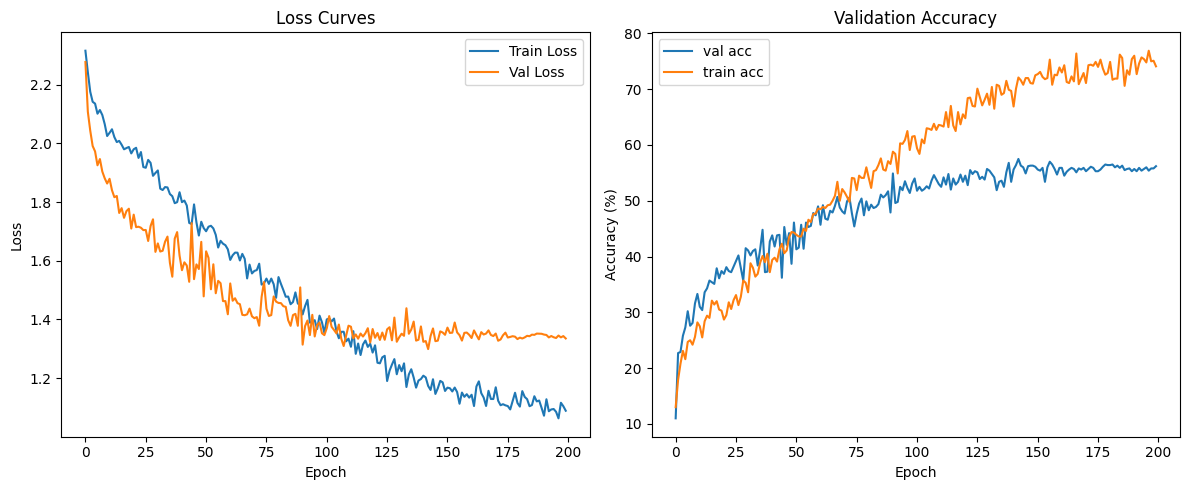

Best Validation Accuracy: 57.50%


In [19]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss Curves')

plt.subplot(1,2,2)
plt.plot(val_accs, label='val acc')
plt.plot(train_accs, label ='train acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.title('Validation Accuracy')
plt.tight_layout(); plt.show()
print(f"Best Validation Accuracy: {best_acc:.2f}%")

In [22]:
test_dataset = CIFAR10('./data', train=False, transform=val_transforms)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

def CalTestAcc(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits, _ = model(imgs)
            _, preds = logits.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()
    test_acc = 100. * correct / total
    return test_acc
test_acc = CalTestAcc(normal_vit, test_loader)
print(f"Test Accuracy: {test_acc:.2f}% (on {total} samples)")

Test Accuracy: 54.97% (on 1000 samples)


# Finetuing MIM weights Strategy 1

In [23]:
MIM_Vit = SmallViT(img_size=32, num_classes=10, embed_dim=384, num_heads=4,
                   num_blocks=4, dropout=0.1, num_reg_tokens=4, conv_stages=3)

mim_path = '/kaggle/working/mim_vit.pth'
mim_state = torch.load(mim_path, map_location=device)


MIM_Vit.stem.stem.load_state_dict(
    {k: v for k, v in mim_state.items() if k.startswith('stem.stem.')}, strict=False)

MIM_Vit.pos_embed.data.copy_(mim_state['pos_embed'])
MIM_Vit.reg_tokens.data.copy_(mim_state['reg_tokens'])

for i in range(len(MIM_Vit.blocks)):
    prefix = f'blocks.{i}.'
    block_state = {k[len(prefix):]: v for k, v in mim_state.items() if k.startswith(prefix)}
    MIM_Vit.blocks[i].load_state_dict(block_state)
    
MIM_Vit = MIM_Vit.to(device)

In [25]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

pretrained_params = []
random_params = []

for name, param in MIM_Vit.named_parameters():
    if 'head' in name or 'peg' in name:
        random_params.append(param)
    else:
        pretrained_params.append(param)

optimizer = optim.AdamW([
    {'params': pretrained_params, 'lr': 5e-5}, # Protect the MIM weights
    {'params': random_params, 'lr': 5e-4}      # Train the random weights quickly
], weight_decay=0.05)

# 3. Use a gentle warmup for the whole system
warmup = LinearLR(optimizer, start_factor=0.1, total_iters=10)
cosine = CosineAnnealingLR(optimizer, T_max=190)
scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[10])

num_epochs = 200
train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_acc = 0.0

print("--- Starting Differential Fine-Tuning ---")

for epoch in range(1, num_epochs+1):
    MIM_Vit.train()
    epoch_train_loss = 0.0
    correct, total = 0, 0
    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs} Train'):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        logits, _ = MIM_Vit(imgs)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(MIM_Vit.parameters(), 1.0)
        optimizer.step()

        epoch_train_loss += loss.item()
        _, preds = torch.max(logits, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_acc = 100. * correct/total
    train_accs.append(train_acc)
    train_losses.append(avg_train_loss)

    # Validation
    MIM_Vit.eval()
    epoch_val_loss = 0.0
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits, _ = MIM_Vit(imgs)
            loss = F.cross_entropy(logits, labels)  
            epoch_val_loss += loss.item()
            _, preds = logits.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()
            
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_acc = 100. * correct / total
    val_accs.append(val_acc)

    scheduler.step()

    print(f"Epoch {epoch}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(MIM_Vit.state_dict(), 'MIM_Vit_best.pth')

--- Starting Differential Fine-Tuning ---


Epoch 1/200 Train: 100%|██████████| 16/16 [00:01<00:00,  9.61it/s]


Epoch 1: Train Loss: 2.3572 | Val Loss: 2.3075 | Train Acc: 10.90% | Val Acc: 9.70%


Epoch 2/200 Train: 100%|██████████| 16/16 [00:01<00:00, 10.08it/s]


Epoch 2: Train Loss: 2.2739 | Val Loss: 2.2228 | Train Acc: 17.30% | Val Acc: 20.20%


...

Epoch 198: Train Loss: 1.6556 | Val Loss: 1.5092 | Train Acc: 46.70% | Val Acc: 45.00%


Epoch 199/200 Train: 100%|██████████| 16/16 [00:01<00:00,  8.63it/s]


Epoch 199: Train Loss: 1.6763 | Val Loss: 1.5095 | Train Acc: 47.20% | Val Acc: 45.50%


Epoch 200/200 Train: 100%|██████████| 16/16 [00:01<00:00,  8.61it/s]


Epoch 200: Train Loss: 1.6791 | Val Loss: 1.5065 | Train Acc: 46.70% | Val Acc: 45.90%


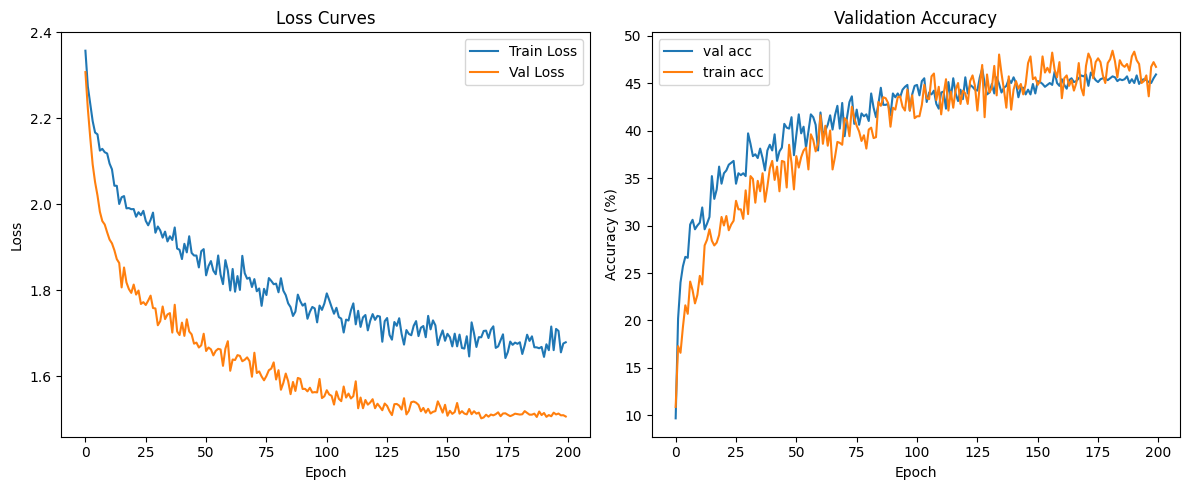

Best Validation Accuracy: 46.50%


In [27]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss Curves')

plt.subplot(1,2,2)
plt.plot(val_accs, label='val acc')
plt.plot(train_accs, label ='train acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.title('Validation Accuracy')
plt.tight_layout(); plt.show()
print(f"Best Validation Accuracy: {best_acc:.2f}%")

In [29]:
test_acc = CalTestAcc(MIM_Vit, test_loader)
print(f"Test Accuracy: {test_acc:.2f}% (on {total} samples)")

Test Accuracy: 45.66% (on 1000 samples)


# strategy 2 full model training with same lr

In [31]:
MIM_Vit2 = SmallViT(img_size=32, num_classes=10, embed_dim=384, num_heads=4,
                   num_blocks=4, dropout=0.1, num_reg_tokens=4, conv_stages=3)


MIM_Vit2.stem.stem.load_state_dict(
    {k: v for k, v in mim_state.items() if k.startswith('stem.stem.')}, strict=False)

MIM_Vit2.pos_embed.data.copy_(mim_state['pos_embed'])
MIM_Vit2.reg_tokens.data.copy_(mim_state['reg_tokens'])

for i in range(len(MIM_Vit2.blocks)):
    prefix = f'blocks.{i}.'
    block_state = {k[len(prefix):]: v for k, v in mim_state.items() if k.startswith(prefix)}
    MIM_Vit2.blocks[i].load_state_dict(block_state)
    
MIM_Vit2 = MIM_Vit2.to(device)


In [32]:
criterion = nn.CrossEntropyLoss() 
optimizer = optim.AdamW(MIM_Vit2.parameters(), lr=5e-4, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

num_epochs = 200
train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_acc = 0.0

for epoch in range(1, num_epochs+1):
    # Training
    MIM_Vit2.train()
    epoch_train_loss = 0.0
    correct, total = 0, 0
    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs} Train'):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        logits, _ = MIM_Vit2(imgs)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(MIM_Vit2.parameters(), 1.0)
        optimizer.step()

        epoch_train_loss += loss.item()
        _, preds = torch.max(logits, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_acc = 100. * correct/total
    train_accs.append(train_acc)
    train_losses.append(avg_train_loss)

    # Validation (unchanged – uses plain CE with integer labels)
    MIM_Vit2.eval()
    epoch_val_loss = 0.0
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits, _ = MIM_Vit2(imgs)
            loss = F.cross_entropy(logits, labels)  # validation uses hard labels
            epoch_val_loss += loss.item()
            _, preds = logits.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_acc = 100. * correct / total
    val_accs.append(val_acc)

    scheduler.step()

    print(f"Epoch {epoch}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train Acc: {train_acc} | Val Acc: {val_acc:.2f}%")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(MIM_Vit2.state_dict(), 'MIM_Vit2.pth')

Epoch 1/200 Train: 100%|██████████| 16/16 [00:01<00:00,  9.49it/s]


Epoch 1: Train Loss: 2.3778 | Val Loss: 2.1541 | Train Acc: 16.0 | Val Acc: 18.70%


Epoch 2/200 Train: 100%|██████████| 16/16 [00:01<00:00,  9.89it/s]


Epoch 2: Train Loss: 2.1359 | Val Loss: 2.0186 | Train Acc: 18.3 | Val Acc: 21.30%


Epoch 3/200 Train: 100%|██████████| 16/16 [00:01<00:00,  9.95it/s]


...

Epoch 198: Train Loss: 0.5906 | Val Loss: 1.6485 | Train Acc: 79.0 | Val Acc: 54.40%


Epoch 199/200 Train: 100%|██████████| 16/16 [00:01<00:00,  8.69it/s]


Epoch 199: Train Loss: 0.6121 | Val Loss: 1.6477 | Train Acc: 80.6 | Val Acc: 54.30%


Epoch 200/200 Train: 100%|██████████| 16/16 [00:01<00:00,  8.65it/s]


Epoch 200: Train Loss: 0.5745 | Val Loss: 1.6423 | Train Acc: 80.0 | Val Acc: 54.80%


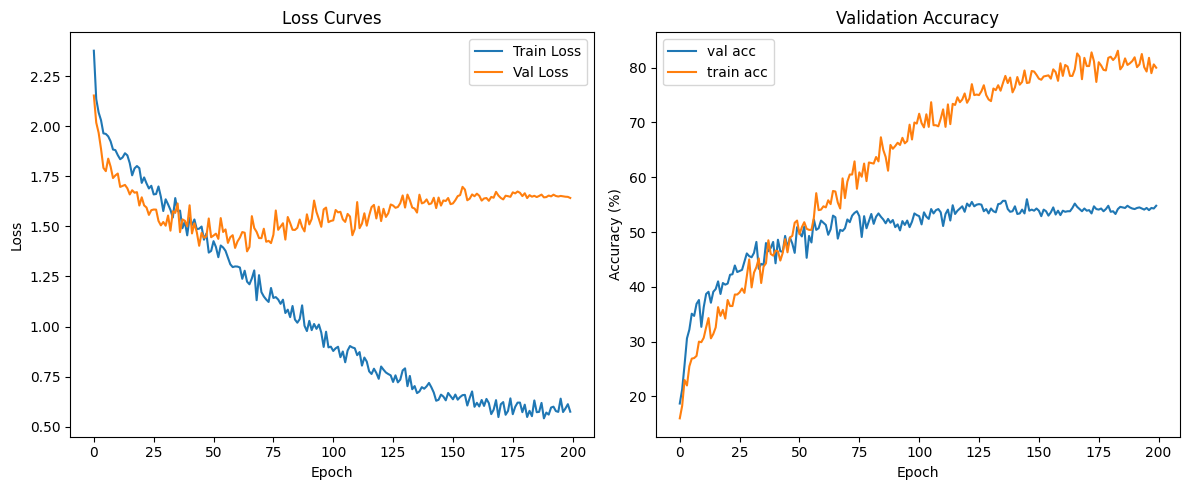

Best Validation Accuracy: 56.00%


In [33]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss Curves')

plt.subplot(1,2,2)
plt.plot(val_accs, label='val acc')
plt.plot(train_accs, label ='train acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.title('Validation Accuracy')
plt.tight_layout(); plt.show()
print(f"Best Validation Accuracy: {best_acc:.2f}%")

In [34]:
test_acc = CalTestAcc(MIM_Vit2, test_loader)
print(f"Test Accuracy: {test_acc:.2f}% (on {total} samples)")

Test Accuracy: 55.70% (on 1000 samples)


# doing kd on mim weights

In [35]:
teacher_path = r'/kaggle/input/models/animesh1811/vit-timm/pytorch/default/1/teacher_vit_small_full.pth'
teacher = torch.load(teacher_path, map_location=device, weights_only=False)
teacher.to(device)
teacher.eval()
for param in teacher.parameters():
    param.requires_grad = False

In [63]:
student = SmallViT(img_size=32, num_classes=10, embed_dim=384, num_heads=4,
                   num_blocks=4, dropout=0.1, num_reg_tokens=4, conv_stages=3)

# Map MIM weights to student
student.stem.stem.load_state_dict(
    {k: v for k, v in mim_state.items() if k.startswith('stem.stem.')}, strict=False)

student.pos_embed.data.copy_(mim_state['pos_embed'])
student.reg_tokens.data.copy_(mim_state['reg_tokens'])

for i in range(len(student.blocks)):
    prefix = f'blocks.{i}.'
    block_state = {k[len(prefix):]: v for k, v in mim_state.items() if k.startswith(prefix)}
    student.blocks[i].load_state_dict(block_state)
    
student = student.to(device)

In [64]:
print(f"{sum(p.numel() for p in student.parameters()) / 1e6:.2f}M")

7.96M


In [65]:
# ---------------------- KD training setup ----------------------
mixup_fn = Mixup(mixup_alpha=0.8, cutmix_alpha=1.0, prob=0.5, num_classes=10)
criterion_ce = SoftTargetCrossEntropy()                    # handles soft labels from mixup
criterion_kd = nn.KLDivLoss(reduction='batchmean')
temperature = 3.0
alpha_kd = 0.75
beta_feat = 0.4

num_epochs = 300
optimizer = optim.AdamW(student.parameters(), lr=5e-4, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

train_losses, val_losses, Train_accs, val_accs = [], [], [], []
best_acc = 0.0

for epoch in range(1, num_epochs+1):
    # Training
    student.train()
    epoch_train_loss = 0.0
    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs} Train'):
        imgs, labels = imgs.to(device), labels.to(device)
        imgs, labels_mixed = mixup_fn(imgs, labels)   # labels become (B, num_classes) soft targets

        student_logits, student_feat  = student(imgs)
        with torch.no_grad():
            # Teacher expects 224x224 input, so resize
            imgs_resized = F.interpolate(imgs, size=(224, 224), mode='bilinear', align_corners=False)
            all_tokens = teacher.forward_features(imgs_resized)
            teacher_feat = all_tokens[:, 0, :]
            teacher_logits = teacher.head(teacher_feat)
            

        # Hard loss with soft targets (mixup outputs)
        loss_ce = criterion_ce(student_logits, labels_mixed)
        # Distillation loss
        loss_kd = criterion_kd(
            F.log_softmax(student_logits / temperature, dim=1),
            F.softmax(teacher_logits / temperature, dim=1)
        ) * (temperature ** 2)

        loss_feat = F.mse_loss(student_feat, teacher_feat)

        loss = alpha_kd * loss_kd + (1 - alpha_kd) * loss_ce + beta_feat * loss_feat

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
        optimizer.step()

        epoch_train_loss += loss.item()
        _, preds = torch.max(student_logits, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    train_acc = 100. * correct/total
    Train_accs.append(train_acc)

    # Validation (unchanged – uses plain CE with integer labels)
    student.eval()
    epoch_val_loss = 0.0
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits, _ = student(imgs)
            loss = F.cross_entropy(logits, labels)  # validation uses hard labels
            epoch_val_loss += loss.item()
            _, preds = logits.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_acc = 100. * correct / total
    val_accs.append(val_acc)

    scheduler.step()

    print(f"Epoch {epoch}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(student.state_dict(), 'best_student.pth')

Epoch 1/300 Train: 100%|██████████| 16/16 [00:05<00:00,  2.68it/s]


Epoch 1: Train Loss: 2.0845 | Val Loss: 2.1796 | Train Acc: 39.90% | Val Acc: 19.10%


Epoch 2/300 Train: 100%|██████████| 16/16 [00:06<00:00,  2.60it/s]


Epoch 2: Train Loss: 1.6931 | Val Loss: 2.1933 | Train Acc: 16.70% | Val Acc: 16.80%


Epoch 3/300 Train: 100%|██████████| 16/16 [00:06<00:00,  2.61it/s]


...

Epoch 298: Train Loss: 0.8823 | Val Loss: 1.0185 | Train Acc: 64.15% | Val Acc: 67.60%


Epoch 299/300 Train: 100%|██████████| 16/16 [00:05<00:00,  2.76it/s]


Epoch 299: Train Loss: 0.8937 | Val Loss: 1.0171 | Train Acc: 60.25% | Val Acc: 67.80%


Epoch 300/300 Train: 100%|██████████| 16/16 [00:05<00:00,  2.75it/s]


Epoch 300: Train Loss: 0.8672 | Val Loss: 1.0169 | Train Acc: 63.45% | Val Acc: 68.00%


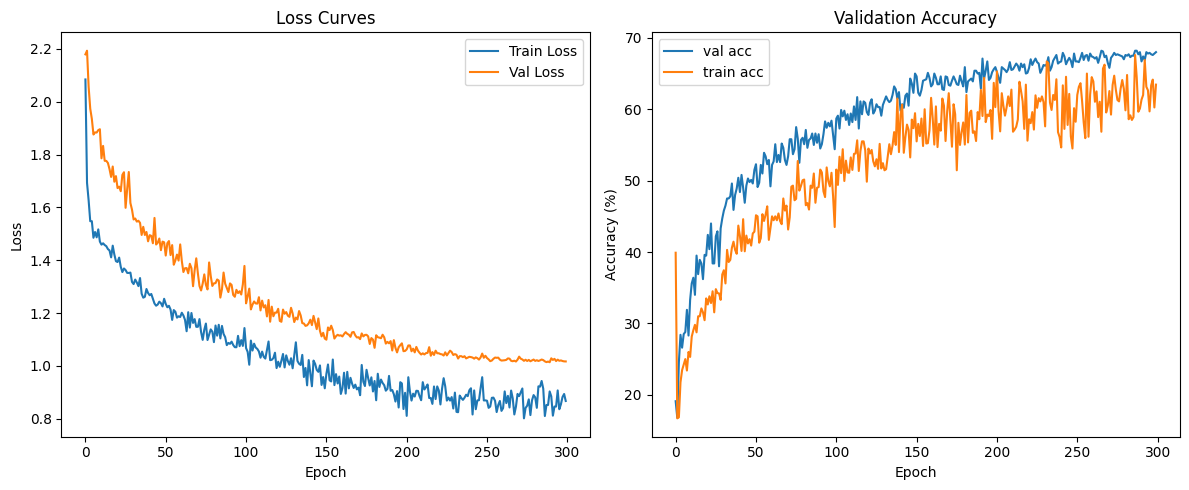

Best Validation Accuracy: 68.20%


In [68]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss Curves')

plt.subplot(1,2,2)
plt.plot(val_accs, label='val acc')
plt.plot(Train_accs, label ='train acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.title('Validation Accuracy')
plt.tight_layout(); plt.show()
print(f"Best Validation Accuracy: {best_acc:.2f}%")

In [69]:
test_acc = CalTestAcc(student, test_loader)
print(f"Test Accuracy (100 per class): {test_acc}%")

Test Accuracy (100 per class): 68.31%
